### 2.1 Linear Regression

> **做什么**：用线性函数拟合连续目标值  

- ### 从零开始线性回归神经网络，并可视化

D:\JupyterNotebook\test\work2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([[6.8953],
        [2.5176],
        [2.1892],
        [2.4418],
        [0.5631],
        [3.8614],
        [0.4088],
        [6.1206],
        [0.5259],
        [6.9350],
        [1.1034],
        [0.0381],
        [9.1395],
        [3.0845],
        [8.6352],
        [1.3919],
        [5.4771],
        [5.8665],
        [4.2173],
        [6.2950]])
tensor([[18.5830],
        [10.6107],
        [10.4900],
        [ 9.7988],
        [ 6.2917],
        [12.7322],
        [ 7.1399],
        [16.9912],
        [ 4.9140],
        [17.7638],
        [ 7.9166],
        [ 5.7200],
        [21.7008],
        [10.9364],
        [22.2531],
        [ 6.2653],
        [16.1235],
        [14.7415],
        [13.8395],
        [18.3861]])


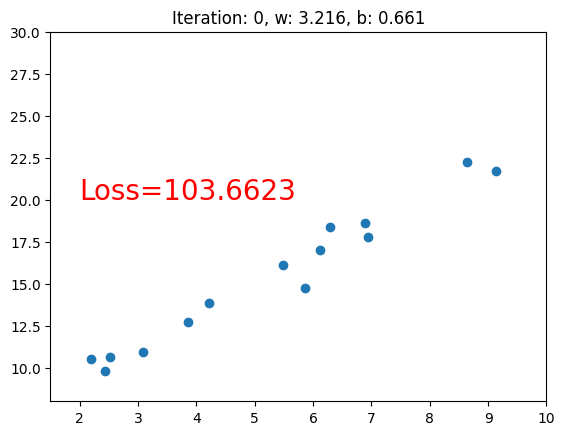

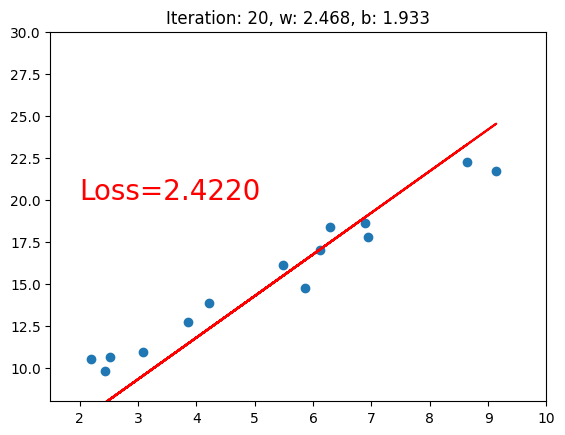

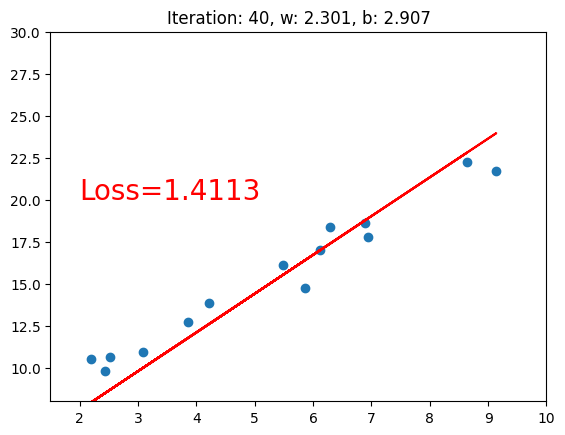

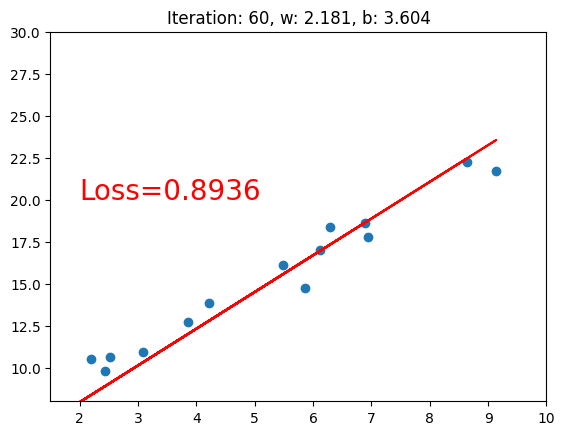

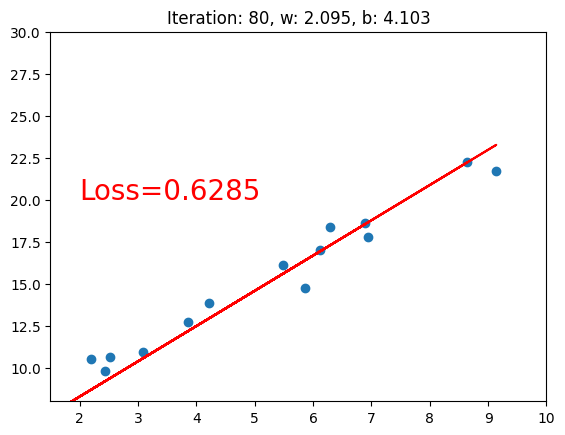

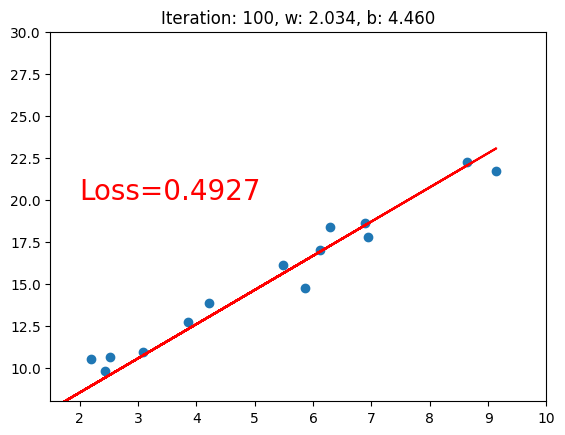

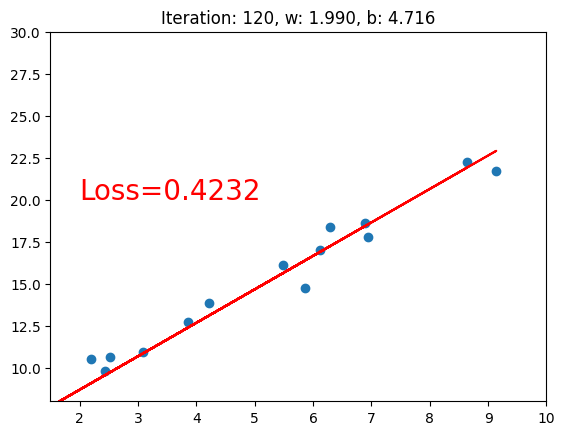

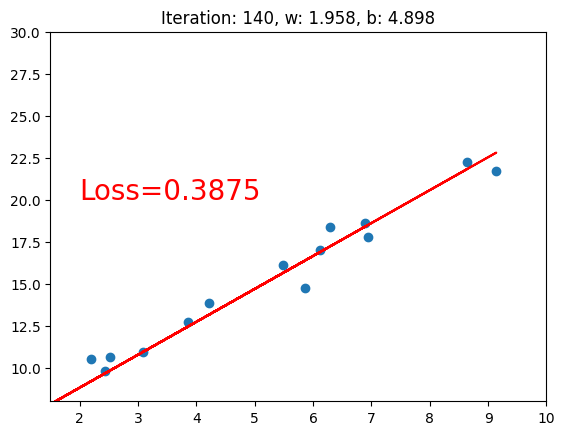

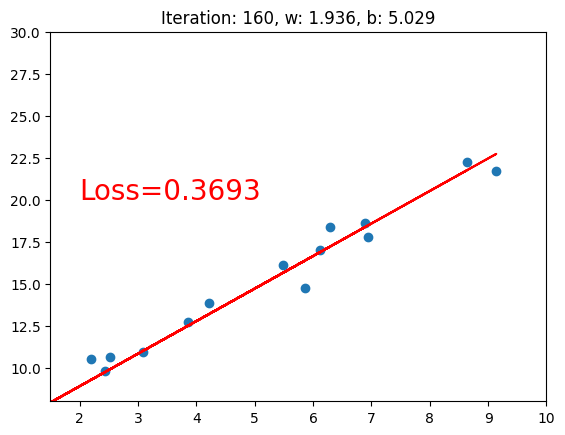

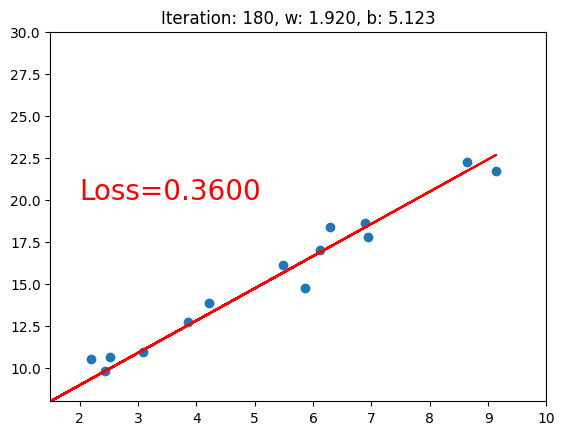

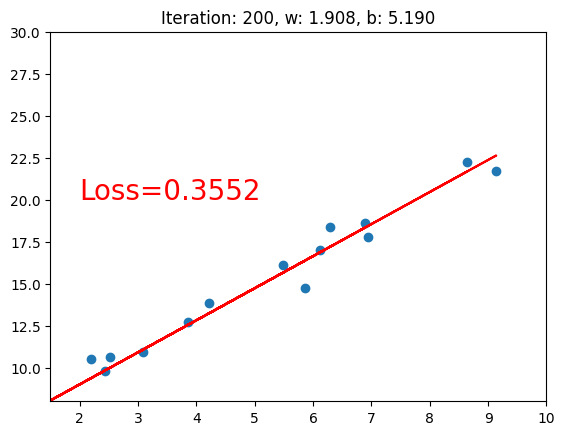

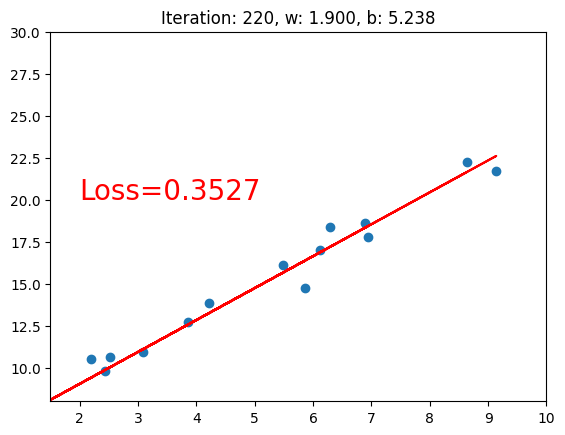

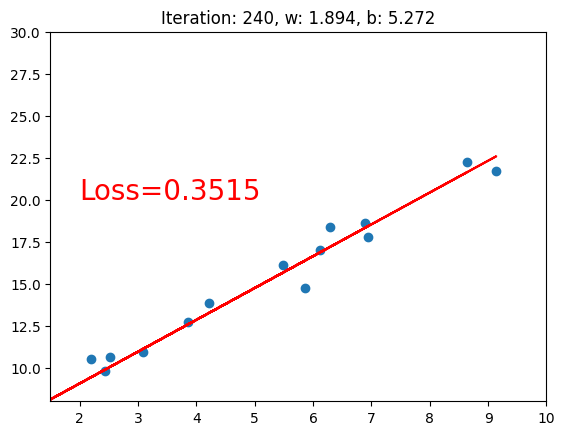

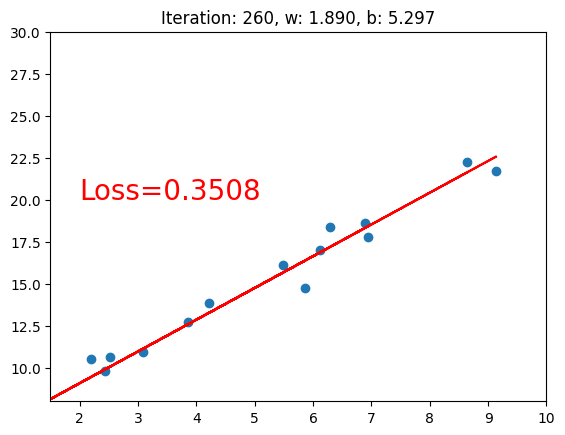

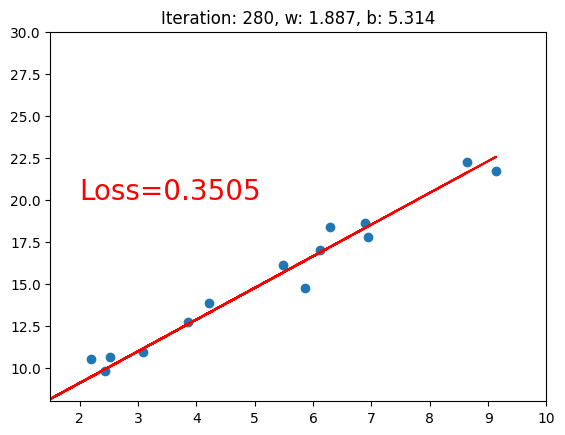

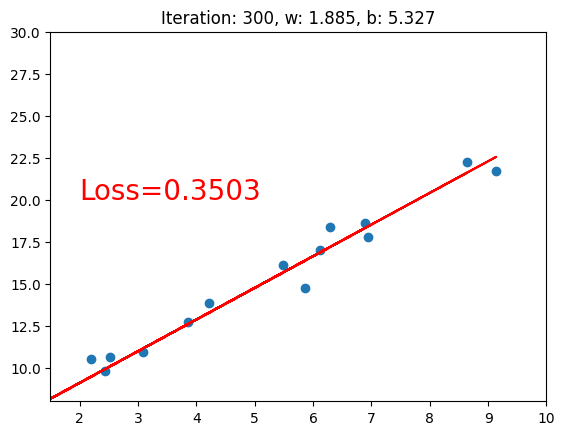

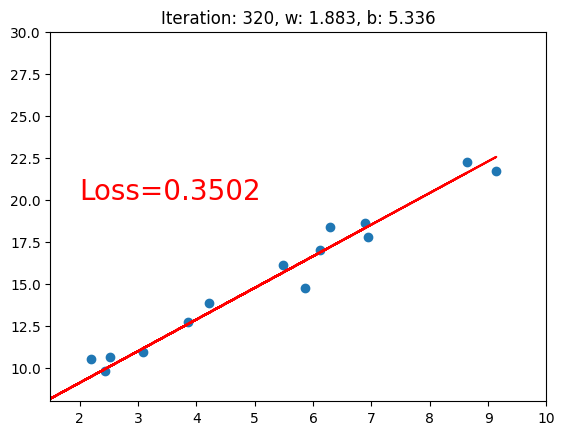

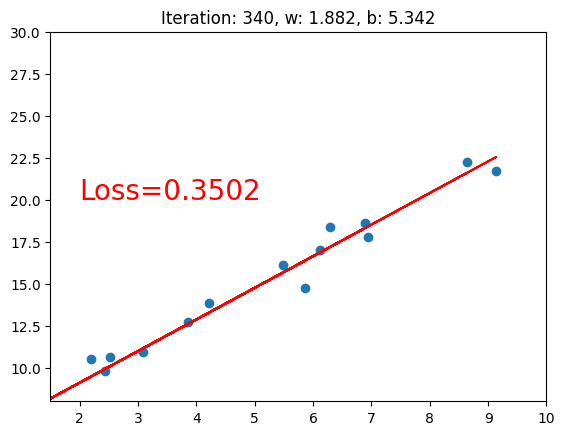

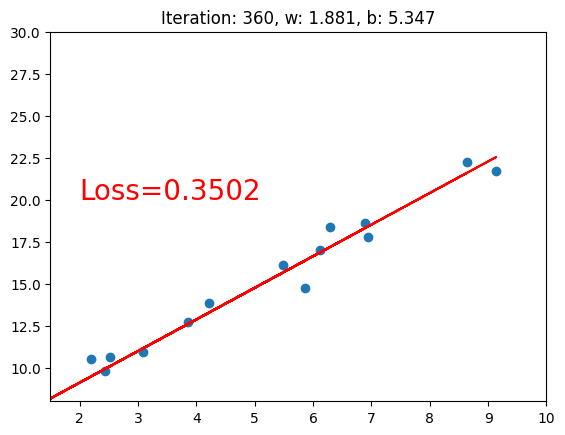

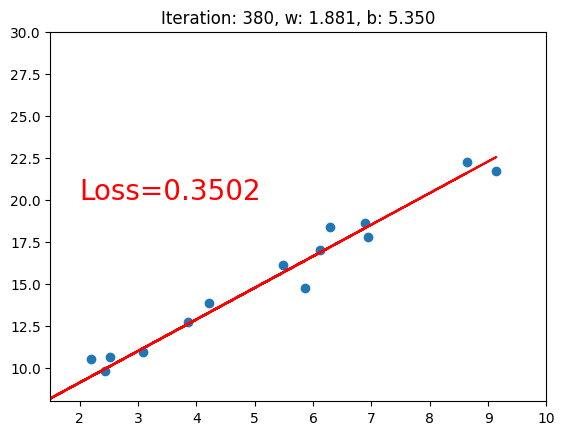

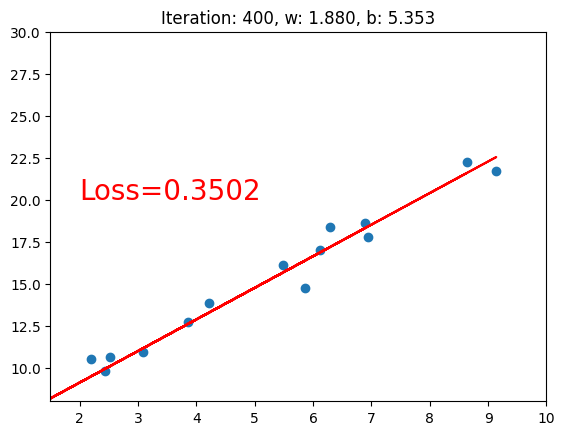

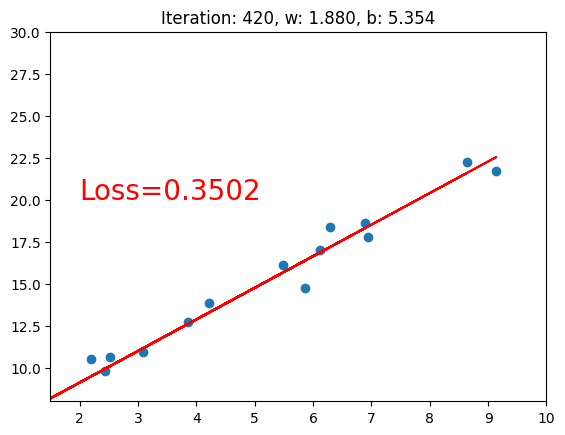

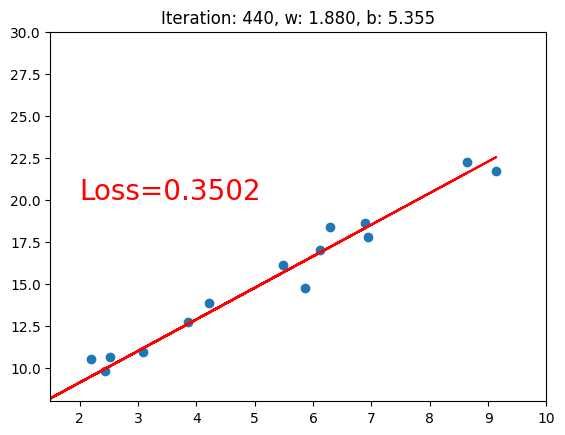

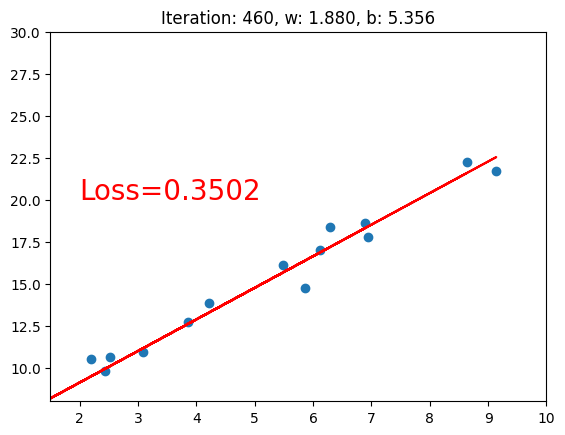

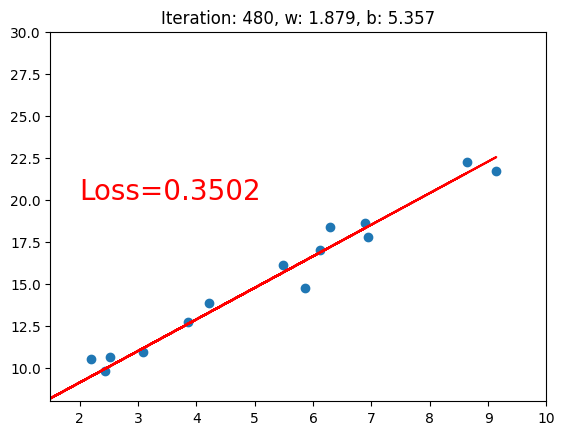

In [1]:
import torch
import matplotlib.pyplot as plt

lr = 0.05  # 原图为 Ir，这里统一改为 lr
x = torch.rand(20, 1) * 10
y = 2 * x + (5 + torch.randn(20, 1))
print(x)
print(y)

w = torch.randn((1), requires_grad=True)
b = torch.zeros((1), requires_grad=True)

for iteration in range(500):
    # 前向传播
    wx = torch.mul(w, x)
    y_predict = torch.add(wx, b)
    # 计算损失 MSE
    loss = (0.5*(y_predict-y)**2).mean()
    # loss 反向传播
    loss.backward()
    # 更新参数（原图是 Ir，这里对应改为 lr）
    w.data.sub_(lr * w.grad)
    b.data.sub_(lr * b.grad)
    # 梯度清零
    w.grad.zero_()
    b.grad.zero_()
    
    # 绘图（修复了 if 语句下方的缩进）
    if iteration % 20 == 0:
        plt.cla()
        plt.scatter(x.data.numpy(), y.data.numpy())  # 实际值的散点图
        plt.plot(x.data.numpy(), y_predict.data.numpy(), c="r")  # 预测直线
        plt.text(2, 20, 'Loss=%0.4f' % loss.data.numpy(), fontdict={'size':'20', 'color':'red'})
        plt.xlim(1.5, 10)
        plt.ylim(8, 30)
        # 修复了 title 占位符数量（原图写了3个参数但只给了1个位置）
        plt.title("Iteration: {}, w: {:.3f}, b: {:.3f}".format(iteration, w.data.numpy()[0], b.data.numpy()[0]))
        plt.pause(0.5)

    if loss.data.numpy() < 0.1:
        break

- ### 线性回归的简洁实现

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#  准备数据 
X = torch.tensor([[1, 2], [2, 3], [3, 4], [4, 5]], dtype=torch.float32)
y = torch.tensor([0, 1, 1, 2])          # 类别从 0 开始

# 封装为 Dataset 和 DataLoader（批次大小为 2，打乱）
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

#  定义模型 
model = nn.Linear(2, 3)                # 输入维度2，输出维度3（类别数）

#  损失函数和优化器 
criterion = nn.CrossEntropyLoss()      # 自带 Softmax + 交叉熵
optimizer = optim.SGD(model.parameters(), lr=0.1)

#  训练 
num_epochs = 1000
for epoch in range(num_epochs):
    for inputs, labels in dataloader:          # 小批量迭代
        optimizer.zero_grad()                  # 梯度清零
        outputs = model(inputs)                # 前向传播（得到 logits）
        loss = criterion(outputs, labels)      # 计算损失
        loss.backward()                        # 反向传播
        optimizer.step()                       # 更新参数

    # 每 100 轮打印一次损失（注意缩进：在 epoch 循环内，batch 循环外）
    if (epoch + 1) % 100 == 0:
        # 注意：这里 loss 是最后一个 batch 的，可改为全量评估更准确，但简洁实现常见如此
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
        
#  预测 
with torch.no_grad():
    logits = model(X)                     # 得到所有样本的 logits
    predictions = torch.argmax(logits, dim=1)
    print("Predictions:", predictions)

Epoch [100/1000], Loss: 0.7706
Epoch [200/1000], Loss: 1.0852
Epoch [300/1000], Loss: 0.5541
Epoch [400/1000], Loss: 0.4128
Epoch [500/1000], Loss: 0.5898
Epoch [600/1000], Loss: 0.2893
Epoch [700/1000], Loss: 0.3874
Epoch [800/1000], Loss: 0.2938
Epoch [900/1000], Loss: 0.1463
Epoch [1000/1000], Loss: 0.2466
Predictions: tensor([0, 1, 1, 2])


- ### **线性回归实操**

<br/>

1.假设下表是你今年每个月的生活费表，请使用线性回归预测自己第12月份的花费是多少？

（提示：模型y=wx+b，x相当于月份， w和b是需要通过建立线性回归模型训练得出的参数）

月份： 1、  2、  3、  4、  5、  6、  7、   8、  9、  10、 11、 12

金额：760、890、820、778、920、830、1200、860、900、990、1000、？

<br/>

要求如下：

（1）使用sklearn的linear_model.LinearRegression()方法建模

（2）根据上表创建训练集，使用fit方法拟合数据；

（3）打印coef_(回归系数)和intercept_（截距）系数；

（4）使用predict方法预测第12月份的花费；

（5）运行查看结果

In [2]:
from sklearn. linear_model import LinearRegression
import numpy as np

months = np. array ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]).reshape (-1, 1)
expenses = np. array ([760, 890, 820, 778, 920, 830, 1200, 860, 900, 990, 1000])

model = LinearRegression()
model. fit (months, expenses)

print('回归系数:',model.coef_)
print ('截距:',model.intercept_)

predicted_expense = model. predict (np. array ([[12]]))
print('预测第12个月的花费:',predicted_expense[0])

回归系数: [20.76363636]
截距: 779.7818181818182
预测第12个月的花费: 1028.9454545454546


2.比较使用numpy的dot方法和使用for循环进行10000000个[0,1]之间随机数相乘的时间差，要求如下：

（1）自定义my_dot方法，接收两个参数a,b (a和b是向量数组)，通过for循环计算a，b的所有乘机的和；

（2）使用numpy的random.rand方法随机产生10000000个[0,1]之间的随机数，随机种子为10；

（3）打印输出调用my_dot方法计算a和b乘积的和的时间；

（4）打印输出调用使用numpy的dot方法计算a和b点积和的时间；

In [4]:
import numpy as np
import time

def my_dot(a, b):
    result = 0
    for i in range(len(a)):
        result += a[i] * b[i]
    return result
    
np.random.seed (10)
a = np.random.rand (10000000)
b = np.random.rand (10000000)

start_time = time.time()
result_my_dot = my_dot(a, b)
end_time = time.time()
execution_time_my_dot = end_time - start_time

start_time = time.time()
result_np_dot = np.dot(a, b)
end_time = time.time()
execution_time_np_dot = end_time - start_time

print("使用for循环计算乘积的和的时间:",execution_time_my_dot)
print("使用numpy的dot方法计算点积和的时间:",execution_time_np_dot)

使用for循环计算乘积的和的时间: 3.5162272453308105
使用numpy的dot方法计算点积和的时间: 0.006084918975830078


3.使用线性回归对波士顿房价进行预测，要求如下：

（1）import引入boston数据集load_boston

（2）加载数据集；

（3）使用pandas查看数据集；

（4）使用info()查看数据集的信息，使用describe()查看数据集的统计描述信息；

（5）划分数据集为训练集占80%，测试集占20%；

（6）使用StandardScaler的fit_transform（）和transform（）方法分别对训练集和测试集的数据进行归一化（使它们的均值为 0，方差为 1）

（7）使用LinearRegression()建立线性回归模型；

（8）打印训练得出的coef_和intercept_参数；

（9）对测试集中的数据进行房价预测；

（10）打印mse均方误差；

（11）使用matplotlib绘制真实值和预测值折线图；

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup   

D:\JupyterNotebook\test\work2\.venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\JupyterNotebook\test\work2\.venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\JupyterNotebook\test\work2\.venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\JupyterNotebook\test\work2\.venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\JupyterNotebook\test\work2\.venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from cu

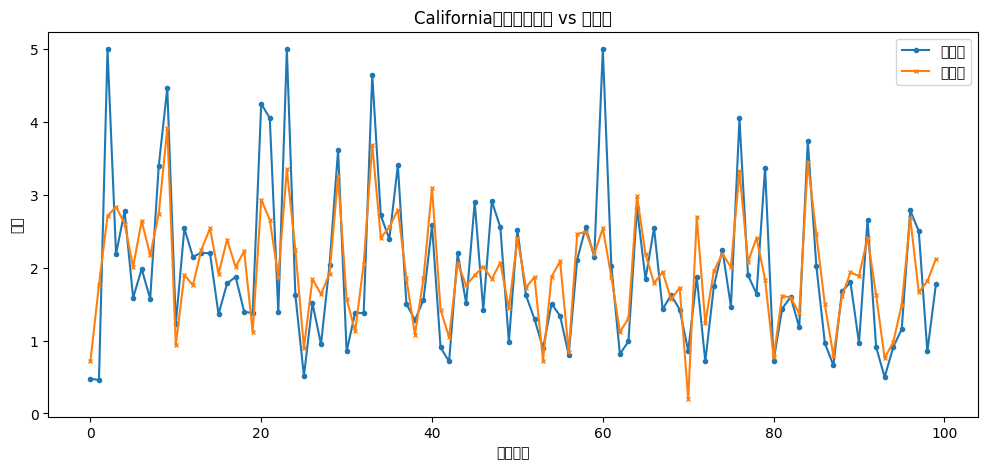

In [5]:
# (1)~(2) 引入并加载数据集
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target

# (3) 使用pandas查看数据集
import pandas as pd

data_df = pd.DataFrame(X, columns=housing.feature_names)
data_df['Price'] = y
print(data_df.head())

# (4) info() 和 describe()
data_df.info()
print(data_df.describe())

# (5) 划分训练集80%，测试集20%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# (6) StandardScaler 归一化
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 训练集：fit + transform
X_test_scaled = scaler.transform(X_test)         # 测试集：只transform，不fit

# (7) 建立线性回归模型
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# (8) 打印系数和截距
print("系数 coef_:", model.coef_)
print("截距 intercept_:", model.intercept_)

# (9) 对测试集预测
y_pred = model.predict(X_test_scaled)

# (10) 打印MSE均方误差
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"MSE均方误差: {mse:.4f}")

# (11) 绘制真实值和预测值折线图
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test[:100], label='真实值', marker='o', markersize=3)
plt.plot(y_pred[:100], label='预测值', marker='x', markersize=3)
plt.xlabel('样本序号')
plt.ylabel('房价')
plt.title('California房价：真实值 vs 预测值')
plt.legend()
plt.show()

### 2.2 Logistic Regression

> **做什么**：二分类，用sigmoid函数输出概率
> **注意**：逻辑回归（二分类）是softmax回归（多分类）在类别数K=2时的特例。当输出类别变为K个时，我们不再使用Sigmoid的函数，而是将其推广为softmax函数，将输出转化为K个类别的概率分布

- ### softmax回归的从零开始实现(仅numpy)

In [5]:
import numpy as np

def softmax(X):
    """Softmax 函数，输入 X 形状 (样本数, 类别数)"""
    exps = np.exp(X)                      # 对每个元素取指数
    return exps / np.sum(exps, axis=1, keepdims=True)  # 按行归一化

def cross_entropy(y_hat, y):
    """交叉熵损失，y_hat 是预测概率矩阵，y 是真实类别索引"""
    return -np.mean(np.log(y_hat[np.arange(len(y)), y]))

def one_hot_encoding(y, num_classes):
    """将类别索引转为 one-hot 编码，返回形状 (样本数, 类别数)"""
    return np.eye(num_classes)[y]

def accuracy(y_hat, y):
    """计算预测准确率"""
    return np.mean(y_hat.argmax(axis=1) == y)

def train(X, y, num_epochs, learning_rate):
    """训练 Softmax 回归模型（梯度下降）"""
    num_examples, num_features = X.shape
    num_classes = len(np.unique(y))

    # 初始化权重和偏置（小随机数）
    W = np.random.normal(0, 0.01, (num_features, num_classes))
    b = np.zeros((1, num_classes))

    for epoch in range(num_epochs):
        # 前向传播
        logits = np.dot(X, W) + b          # 线性得分
        y_hat = softmax(logits)            # 概率预测

        # 计算损失和准确率
        loss = cross_entropy(y_hat, y)
        acc = accuracy(y_hat, y)

        # 反向传播：计算梯度
        grad_logits = y_hat - one_hot_encoding(y, num_classes)
        grad_W = np.dot(X.T, grad_logits)   # 权重梯度
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)  # 偏置梯度

        # 更新参数（注意：原图错写成 ==，这里改为 =）
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b

        # 每 100 轮打印一次信息
        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    return W, b

# ---------- 测试 ----------
if __name__ == "__main__":
    # 人造数据（4个样本，每个2个特征，3个类别）
    X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
    y = np.array([0, 1, 1, 2])

    W, b = train(X, y, num_epochs=1000, learning_rate=0.1)

    # 预测
    logits = np.dot(X, W) + b
    y_hat = softmax(logits)
    predictions = np.argmax(y_hat, axis=1)
    print("Predictions:", predictions)

Epoch [100/1000], Loss: 1.2564, Accuracy: 0.5000
Epoch [200/1000], Loss: 0.8282, Accuracy: 0.5000
Epoch [300/1000], Loss: 0.5521, Accuracy: 0.7500
Epoch [400/1000], Loss: 0.3641, Accuracy: 0.7500
Epoch [500/1000], Loss: 0.1543, Accuracy: 1.0000
Epoch [600/1000], Loss: 0.1373, Accuracy: 1.0000
Epoch [700/1000], Loss: 0.1246, Accuracy: 1.0000
Epoch [800/1000], Loss: 0.1143, Accuracy: 1.0000
Epoch [900/1000], Loss: 0.1057, Accuracy: 1.0000
Epoch [1000/1000], Loss: 0.0984, Accuracy: 1.0000
Predictions: [0 1 1 2]


- ### softmax回归的简洁实现（PyTorch）

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 准备数据
X = torch.tensor([[1, 2], [2, 3], [3, 4], [4, 5]], dtype=torch.float32)
y = torch.tensor([0, 1, 1, 2])          # 类别从 0 开始

# 封装为 Dataset 和 DataLoader（批次大小为 2，打乱）
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# 定义模型
model = nn.Linear(2, 3)                # 输入维度2，输出维度3（类别数）

# ---------- 损失函数和优化器 ----------
criterion = nn.CrossEntropyLoss()      # 自带 Softmax + 交叉熵
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 训练 
num_epochs = 1000
for epoch in range(num_epochs):
    for inputs, labels in dataloader:          # 小批量迭代
        optimizer.zero_grad()                  # 梯度清零
        outputs = model(inputs)                # 前向传播（得到 logits）
        loss = criterion(outputs, labels)      # 计算损失
        loss.backward()                        # 反向传播
        optimizer.step()                       # 更新参数

    # 每 100 轮打印一次损失（注意缩进：在 epoch 循环内，batch 循环外）
    if (epoch + 1) % 100 == 0:
        # 注意：这里 loss 是最后一个 batch 的，可改为全量评估更准确，但简洁实现常见如此
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
        
        # 预测 
with torch.no_grad():
    logits = model(X)                     # 得到所有样本的 logits
    predictions = torch.argmax(logits, dim=1)
    print("Predictions:", predictions)

Epoch [100/1000], Loss: 1.5356
Epoch [200/1000], Loss: 0.5301
Epoch [300/1000], Loss: 0.3429
Epoch [400/1000], Loss: 0.6124
Epoch [500/1000], Loss: 0.2975
Epoch [600/1000], Loss: 0.4881
Epoch [700/1000], Loss: 0.1845
Epoch [800/1000], Loss: 0.3100
Epoch [900/1000], Loss: 0.2823
Epoch [1000/1000], Loss: 0.1361
Predictions: tensor([0, 1, 1, 2])


- ### **逻辑回归实操**

<br/>
1.基于逻辑回归实现乳腺癌预测，对sklearn自带的数据集breast_cancer进行乳腺癌预测，

<br/>

要求如下：

（1）加载breast_cancer 数据集；

（2）使用pandas查看数据集信息；

（3）使用sklearn的train_test_split拆分数据集为训练集和测试集（20%）；

（4）建立回归模型；

（5）对测试集进行预测；

（6）打印准确率accuracy_score分数

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# 加载数据
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.head())

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 建立逻辑回归模型
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

# 预测与评估
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"乳腺癌预测准确率: {accuracy:.4f}")

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

2. 基于逻辑回归实现鸢尾花预测，对sklearn自带的数据集鸢尾花iris进行分类预测，鸢尾花卉数据集包含150个条目，分为3类，每类50个数据，每个数据包含4个属性。可通过花萼长度，花萼宽度，花瓣长度，花瓣宽度4个属性预测鸢尾花卉属于（Setosa，Versicolour，Virginica）三个种类中的哪一类。

要求如下：
（1）加载鸢尾花数据集；

（2）使用pandas查看数据集条目，以及数据集信息和相关统计信息；

（3）划分数据集为训练集占80%，测试集占20%；

（4）使用StandardScaler的fit_transform（）和transform（）方法分别对训练集和测试集的数据进行归一化（使它们的均值为 0，方差为 1）

（5）使用LogisticRegression方法建立逻辑回归模型；

（6）对测试数据进行预测，打印测试集的预测结果；

（7）打印准确率accuracy_score分数；

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# 加载数据
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.head())
print(df.info())
print(df.describe())

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 归一化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 建立逻辑回归模型
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# 预测与评估
y_pred = lr.predict(X_test_scaled)
print(f"测试集预测结果: {y_pred}")
accuracy = accuracy_score(y_test, y_pred)
print(f"准确率: {accuracy:.4f}")

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float

3. 基于逻辑回归实现泰坦尼克生存预测

数据集字段说明：
PassengerId（乘客ID）、survived(存活与否) 0 = No, 1 = Yes、Pclass（客舱等级，在当时的英国阶级分层比较严重，较为重要）
Name（姓名）、Sex（性别）、Age（年龄）、Parch（直系亲友，是指父母，孩子，其中1表示有一个，依次类推）
SibSp（旁系，是指兄弟姐妹）、Ticket（票编号）、Fare（票价）、Cabin（客舱编号）、Embarked（上船的港口编号，是指从不同的港口上船）

要求如下：

（1）使用pandas读取train.csv和test.csv，并查看数据集信息；

（2）使用info（）方法查看训练集哪些字段有缺失数据；

（4）对缺失数据进行填充，对其他字段进行数据清洗；

（3）将train.csv里的数据进行拆分，分为训练集和测试集；

（5）使用LogisticRegression方法建立逻辑回归模型；

（6）对测试数据进行预测，打印测试集的预测结果；

（7）打印准确率accuracy_score分数

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. 加载数据 
train_df = pd.read_csv("D:/JupyterNotebook/titanic_train.csv")
train_df.info()

# 2. 数据预处理 

# 舍弃与生存无关的字段
train_df = train_df.drop(["PassengerId", "Name", "Ticket"], axis=1)

# Cabin字段：判断是否为空，为空则True，否则False
train_df["cabin"] = train_df["Cabin"].isna()

# Age字段：用中位数填充缺失值
train_df["Age"].fillna(train_df["Age"].median(), inplace=True)

# Embarked字段：用出现最多的港口'S'填充缺失值
train_df["Embarked"].fillna("S", inplace=True)

# 确认无缺失值
train_df.info()

# 3. 特征编码 

# get_dummies：将字符型转为one-hot编码
train_df = pd.get_dummies(train_df)

# 4. 拆分特征和标签 
train_data = train_df.drop("Survived", axis=1)
train_target = train_df["Survived"]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    train_data, train_target, test_size=0.2, random_state=42
)

# 5. 建立模型 
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# 6. 预测与评估
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"泰坦尼克号生存预测准确率: {accuracy:.4f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non

### 2.3 Decision Tree（决策树）

> **做什么**：通过特征条件递归划分样本空间 

- ### **决策树实操**

<br/>

1.基于决策树ID3算法实现鸢尾花分类，对sklearn自带的数据集iris鸢尾花进行分类预测，要求如下：

（1）加载iris数据集；

（2）使用pandas查看数据集信息；

（3）使用sklearn的train_test_split拆分数据集为训练集和测试集，其中测试集占20%；

（4）基于信息熵（ID3 算法）建立决策树模型；

（5）对测试集进行预测；

（6）打印准确率accuracy_score分数；

（7）使用graphviz绘制决策树图形，决策树结点使用iris特征名称，生成id3_iris.pdf文件

In [12]:
!pip install graphviz

Looking in indexes: https://mirrors.ustc.edu.cn/pypi/web/simple
  Using cached https://mirrors.ustc.edu.cn/pypi/packages/de/5e/fcbb22c68208d39edff467809d06c9d81d7d27426460ebc598e55130c1aa/graphviz-0.20.1-py3-none-any.whl (47 kB)


===== 鸢尾花数据集信息 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   target_name        150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB
None

前5行：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0   

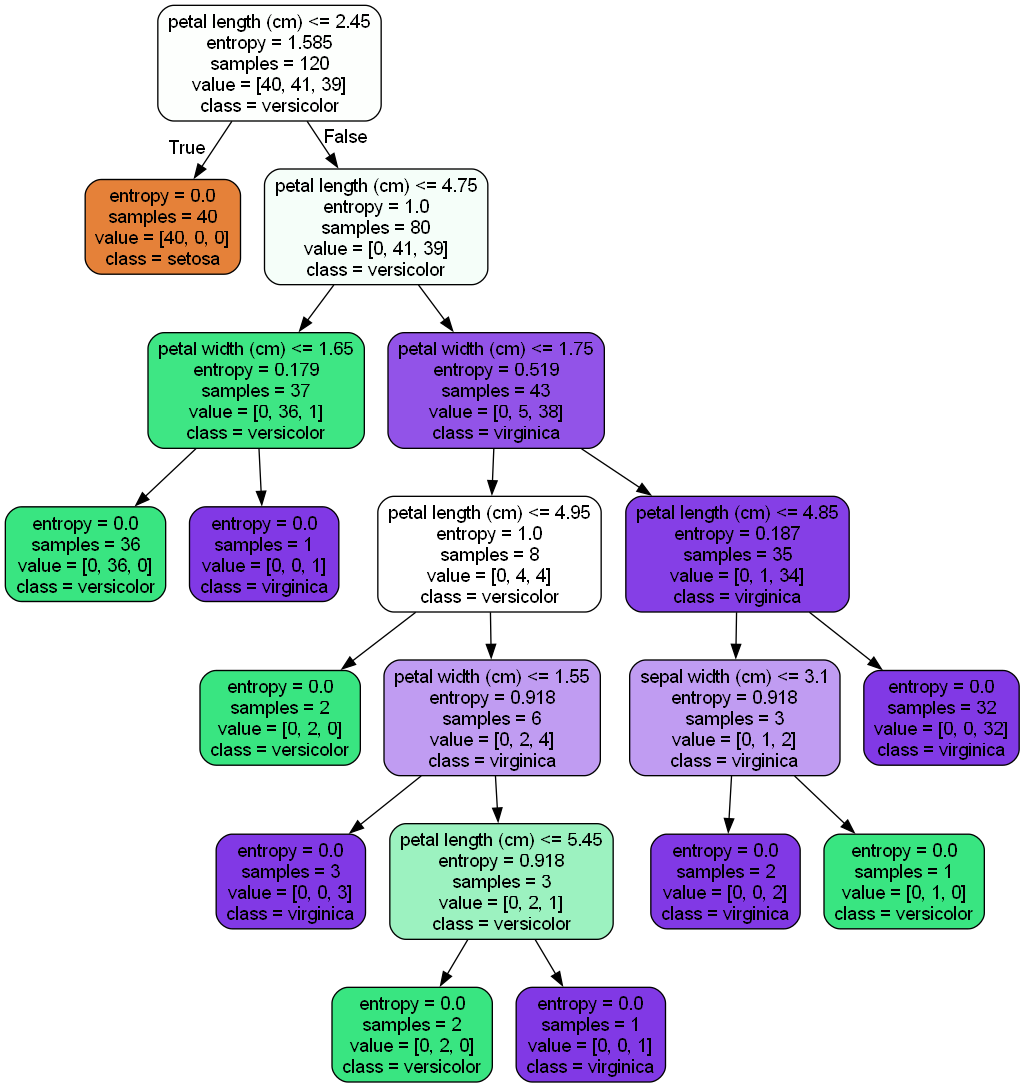

In [16]:
import graphviz
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz
from IPython.display import Image

# (1) 加载iris数据集
iris = load_iris()

# (2) 使用pandas查看数据集信息
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_name'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print("===== 鸢尾花数据集信息 =====")
print(iris_df.info())
print("\n前5行：")
print(iris_df.head())

# (3) 拆分数据集，测试集占20%
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)
print(f"\n训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")

# (4) 基于信息熵（ID3算法）建立决策树
clf_id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_id3.fit(X_train, y_train)

# (5) 对测试集进行预测
y_pred = clf_id3.predict(X_test)

# (6) 打印准确率
acc = accuracy_score(y_test, y_pred)
print(f"\nID3决策树准确率: {acc:.4f}")

# (7) 使用graphviz绘制决策树
dot_data = export_graphviz(
    clf_id3,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
graph = graphviz.Source(dot_data)

# 直接渲染成png显示在Notebook里
graph.format = 'png'
graph.render('id3_iris')
Image('id3_iris.png')

### 2.4 Naive Bayes

> **做什么**：基于贝叶斯定理+特征独立假设的概率分类器  

- ### **朴素贝叶斯实操**

<br/>

以下代码演示了一个文本分类示例，结合了多项式朴素贝叶斯算法和PCA降维可视化

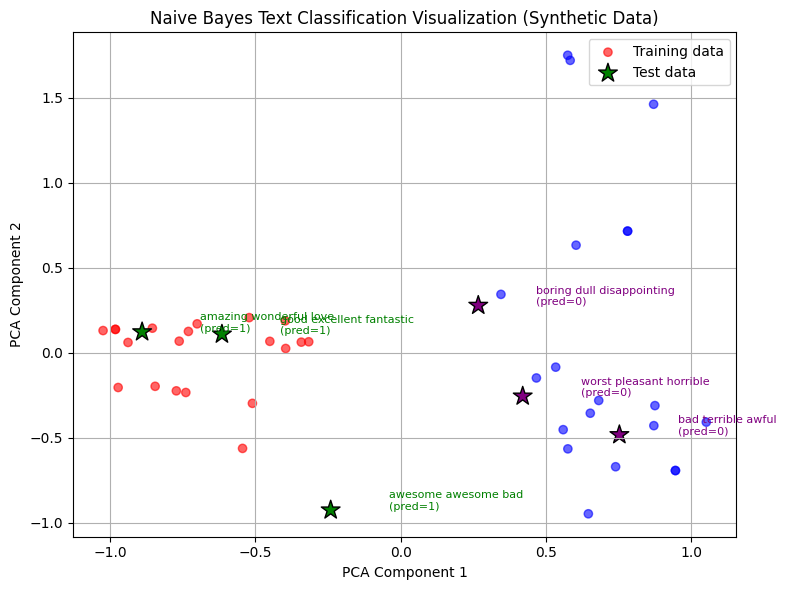

"good excellent fantastic": predicted class 1
"bad terrible awful": predicted class 0
"amazing wonderful love": predicted class 1
"boring dull disappointing": predicted class 0
"awesome awesome bad": predicted class 1
"worst pleasant horrible": predicted class 0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
 
# 1. Create a synthetic, clearly separable dataset
positive_words = ["good", "excellent", "fantastic", "amazing", "wonderful", "love", "great", "awesome", "nice", "pleasant"]
negative_words = ["bad", "terrible", "awful", "horrible", "hate", "worst", "boring", "poor", "dull", "disappointing"]
 
np.random.seed(0)
 
# 20 positive and 20 negative samples
texts = []
labels = []
for _ in range(20):
    sample = " ".join(np.random.choice(positive_words, size=3, replace=True))
    texts.append(sample)
    labels.append(1)
for _ in range(20):
    sample = " ".join(np.random.choice(negative_words, size=3, replace=True))
    texts.append(sample)
    labels.append(0)
 
# 2. Vectorize
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)
 
# 3. Train Naive Bayes
nb = MultinomialNB()
nb.fit(X, labels)
 
# 4. Prepare test samples
test_texts = [
    "good excellent fantastic",   # positive
    "bad terrible awful",         # negative
    "amazing wonderful love",     # positive
    "boring dull disappointing",  # negative
    "awesome awesome bad",        # mixed
    "worst pleasant horrible",    # mixed
]
X_test = vectorizer.transform(test_texts)
y_pred = nb.predict(X_test)
 
# 5. Project to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_all = np.vstack([X.toarray(), X_test.toarray()])
X_all_2d = pca.fit_transform(X_all)
X_2d = X_all_2d[:len(X.toarray())]
X_test_2d = X_all_2d[len(X.toarray()):]
 
# 6. Plot training data
plt.figure(figsize=(8, 6))
colors = ['red' if label == 1 else 'blue' for label in labels]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.6, label='Training data')
 
# 7. Plot test data
test_colors = ['green' if pred == 1 else 'purple' for pred in y_pred]
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=test_colors, marker='*', s=200, edgecolor='k', label='Test data')
for i, txt in enumerate(test_texts):
    plt.annotate(f"{txt}\n(pred={y_pred[i]})", (X_test_2d[i, 0]+0.2, X_test_2d[i, 1]), fontsize=8, color=test_colors[i])
 
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Naive Bayes Text Classification Visualization (Synthetic Data)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
 
# 8. Output predictions
for text, pred in zip(test_texts, y_pred):
    print(f'"{text}": predicted class {pred}')

### 2.5 KNN有监督

> **做什么**：广泛应用于分类和回归任务。
> 需要标签

- ### KNN有监督实操

1.基于k近邻有监督学习实现鸢尾花分类，对sklearn自带的数据集iris鸢尾花进行分类预测，
要求如下：

（1）加载iris数据集；

（2）使用pandas查看数据集信息；

（3）选取花萼的长度和花瓣的长度作为训练集；

（4）使用sklearn的train_test_split拆分数据集为训练集和测试集，其中测试集占20%；

（5）建立KNN模型，k=3；

（6）对测试集进行预测；

（7）打印准确率accuracy_score分数，

（8）再设置k=5，对测试集进行预测，打印准确率accuracy_score分数

In [8]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# (1) 加载iris数据集
iris = load_iris()

# (2) 使用pandas查看数据集信息
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_name'] = iris_df['target'].map(
    {0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print("===== 鸢尾花数据集信息 =====")
print(iris_df.info())
print("\n前5行：")
print(iris_df.head())

# (3) 选取花萼长度(sepal length)和花瓣长度(petal length)作为特征
# sepal length = 第0列, petal length = 第2列
X = iris.data[:, [0, 2]]  # 取第0列和第2列
y = iris.target
print(f"\n选取的特征：花萼长度 + 花瓣长度")
print(f"特征形状: {X.shape}")

# (4) 拆分数据集，测试集占20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")

# (5) 建立KNN模型，k=3
knn_3 = KNeighborsClassifier(n_neighbors=3)

# (6) 对测试集进行预测
knn_3.fit(X_train, y_train)
y_pred_3 = knn_3.predict(X_test)

# (7) 打印准确率
acc_3 = accuracy_score(y_test, y_pred_3)
print(f"\nk=3 时准确率: {acc_3:.4f}")

# (8) 再设置k=5，预测并打印准确率
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train, y_train)
y_pred_5 = knn_5.predict(X_test)
acc_5 = accuracy_score(y_test, y_pred_5)
print(f"k=5 时准确率: {acc_5:.4f}")

===== 鸢尾花数据集信息 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   target_name        150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB
None

前5行：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0   

### 2.5 KNN无监督

> **做什么**：找最近邻，常用于异常检测
> 🙅‍不需要标签

- ### KNN无监督实操 

1.基于k近邻无监督学习找出鸢尾花数据聚集中的异常花朵，对sklearn自带的数据集iris鸢尾花进行异常花朵检测，

要求如下：

（1）加载iris数据集；

（2）使用pandas查看数据集信息；

（3）选取花萼的长度和宽度作为训练集；

（4）使用matplotlib.pyplot方法画出数据集散点图；

（5）使用NearestNeighbors建立无监督最近邻模型（k=3）；

（6）对训练集进行fit拟合训练；

（7）使用模型的kneighbors方法得出每个点和其他3个点的距离distances,以及三个点的索引indexes，

（8）查看每个点的距离均值；

（9）使用matplotlib.pyplot 画图观测每个点的k 距离平均值；

（10）选择 >0.15 作为作为异常点，获得异常点的索引和其值;

（11）使用matplotlib.pyplot 再次画出数据集散点图，异常值设为红色点。

===== 鸢尾花数据集信息 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None

前5行：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   

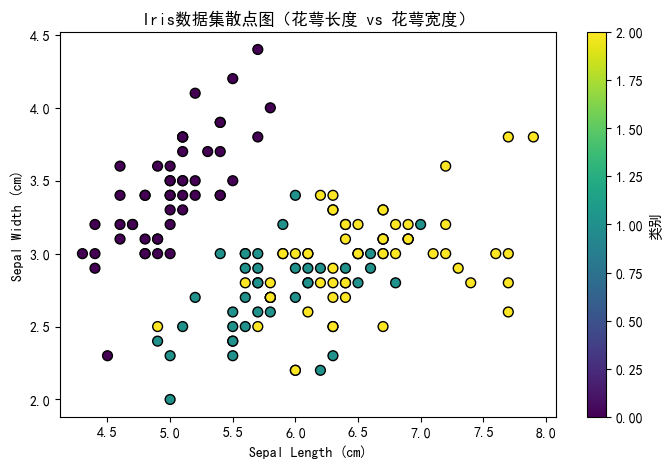


距离数组形状: (150, 3)
索引数组形状: (150, 3)
前5个点的距离:
[[0.         0.         0.1       ]
 [0.         0.1        0.1       ]
 [0.         0.         0.1       ]
 [0.         0.1        0.14142136]
 [0.         0.1        0.1       ]]
前5个点的邻居索引:
[[ 0 17 40]
 [ 1 25  9]
 [ 2 29 47]
 [ 3 47  2]
 [ 4 37 40]]

每个点的k距离均值（前10个）：
[0.05       0.1        0.05       0.12071068 0.1        0.1
 0.2        0.05       0.12071068 0.05      ]


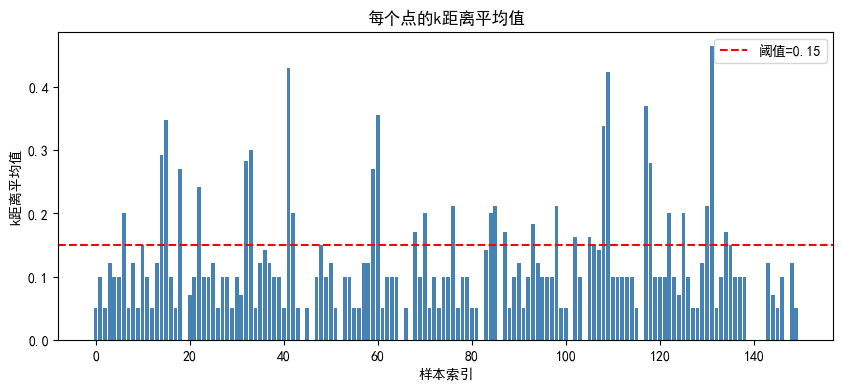


异常点数量: 33
异常点索引: [  6  10  14  15  18  22  32  33  41  42  48  59  60  68  70  76  84  85
  87  93  98 102 105 108 109 117 118 122 125 130 131 134 135]
异常点值:
[[4.6 3.4]
 [5.4 3.7]
 [5.8 4. ]
 [5.7 4.4]
 [5.7 3.8]
 [4.6 3.6]
 [5.2 4.1]
 [5.5 4.2]
 [4.5 2.3]
 [4.4 3.2]
 [5.3 3.7]
 [5.2 2.7]
 [5.  2. ]
 [6.2 2.2]
 [5.9 3.2]
 [6.8 2.8]
 [5.4 3. ]
 [6.  3.4]
 [6.3 2.3]
 [5.  2.3]
 [5.1 2.5]
 [7.1 3. ]
 [7.6 3. ]
 [6.7 2.5]
 [7.2 3.6]
 [7.7 3.8]
 [7.7 2.6]
 [7.7 2.8]
 [7.2 3.2]
 [7.4 2.8]
 [7.9 3.8]
 [6.1 2.6]
 [7.7 3. ]]


D:\JupyterNotebook\test\work2\.venv\lib\site-packages\ipykernel_launcher.py:85: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


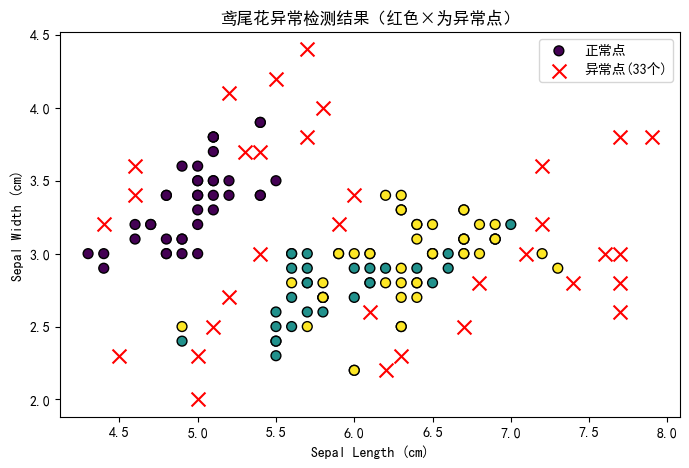

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import NearestNeighbors

# 设置中文显示（防止中文标题乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# (1) 加载iris数据集
iris = load_iris()

# (2) 使用pandas查看数据集信息
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
print("===== 鸢尾花数据集信息 =====")
print(iris_df.info())
print("\n前5行：")
print(iris_df.head())

# (3) 选取花萼长度(sepal length)和花萼宽度(sepal width)作为训练集
# sepal length = 第0列, sepal width = 第1列
X = iris.data[:, [0, 1]]
print(f"\n选取的特征：花萼长度 + 花萼宽度")
print(f"特征形状: {X.shape}")

# (4) 画出数据集散点图
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=iris.target, cmap='viridis', s=50, edgecolors='k')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris数据集散点图（花萼长度 vs 花萼宽度）')
plt.colorbar(label='类别')
plt.show()

# (5) 使用NearestNeighbors建立无监督最近邻模型（k=3）
nn = NearestNeighbors(n_neighbors=3)

# (6) 对训练集进行fit
nn.fit(X)

# (7) kneighbors方法得出每个点和其他3个点的距离和索引
distances, indexes = nn.kneighbors(X)
print(f"\n距离数组形状: {distances.shape}")
print(f"索引数组形状: {indexes.shape}")
print(f"前5个点的距离:\n{distances[:5]}")
print(f"前5个点的邻居索引:\n{indexes[:5]}")

# (8) 查看每个点的距离均值
# 注意：第0列是自身到自身的距离(=0)，取后k个邻居的均值
# distances第0列是0（自己到自己），所以取第1列到末列求均值
mean_distances = distances[:, 1:].mean(axis=1)
print(f"\n每个点的k距离均值（前10个）：")
print(mean_distances[:10])

# (9) 画图观测每个点的k距离平均值
plt.figure(figsize=(10, 4))
plt.bar(range(len(mean_distances)), mean_distances, color='steelblue')
plt.axhline(y=0.15, color='red', linestyle='--', label='阈值=0.15')
plt.xlabel('样本索引')
plt.ylabel('k距离平均值')
plt.title('每个点的k距离平均值')
plt.legend()
plt.show()

# (10) 选择 > 0.15 作为异常点，获得异常点的索引和值
anomaly_mask = mean_distances > 0.15
anomaly_indices = np.where(anomaly_mask)[0]
anomaly_values = X[anomaly_indices]
print(f"\n异常点数量: {len(anomaly_indices)}")
print(f"异常点索引: {anomaly_indices}")
print(f"异常点值:\n{anomaly_values}")

# (11) 再次画出散点图，异常值为红色点
plt.figure(figsize=(8, 5))
# 正常点
normal_mask = ~anomaly_mask
plt.scatter(X[normal_mask, 0], X[normal_mask, 1],
            c=iris.target[normal_mask], cmap='viridis',
            s=50, edgecolors='k', label='正常点')
# 异常点（红色）
plt.scatter(anomaly_values[:, 0], anomaly_values[:, 1],
            c='red', s=100, edgecolors='k', marker='x',
            label=f'异常点({len(anomaly_indices)}个)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('鸢尾花异常检测结果（红色×为异常点）')
plt.legend()
plt.show()